# Greedy Convergence on Random ER Graphs

?? notebook ?????**???????? ER DAG** ??? `dag_greedy_A` / `dag_greedy_A_directed`????

- ???? ER ???? SEM ??
- ??????????????
- ????????? greedy ????
- ???????????????????????

????????????????????????

In [30]:
# 1) Environment and imports
import os
import sys
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start_path: str) -> str:
    cur = os.path.abspath(start_path)
    while True:
        if (
            os.path.exists(os.path.join(cur, 'synthetic_dataset.py'))
            and os.path.isdir(os.path.join(cur, 'coordinate_descent'))
        ):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            raise RuntimeError('Could not locate repo root from current working directory.')
        cur = parent


repo_root = find_repo_root(os.getcwd())
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from MEC import is_in_markov_equiv_class
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0, f as f_A
from coordinate_descent.cd_greedy_A import dag_greedy_A, dag_greedy_A_directed

np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')

print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)
print('Imports ready.')

Python   : 3.12.3
Repo root: c:\Users\super\DAG
Imports ready.


In [31]:
# 2) Helpers
GREEDY_FNS = {
    'pair': dag_greedy_A
}

PLOT_COLORS = {
    'cd_A_noepoch': 'steelblue',
    'greedy_pair': 'darkorange',
    'greedy_directed': 'seagreen',
}


def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> int:
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return int(dist)


def build_true_A(B_true: np.ndarray, noise_scales) -> np.ndarray:
    noise_scales = np.asarray(noise_scales, dtype=float)
    return (np.eye(B_true.shape[0]) - B_true) @ np.diag(1.0 / noise_scales)


def generate_er_trial(cfg: dict, seed: int) -> dict:
    dataset = SyntheticDataset(
        n=cfg['n_samples'],
        d=cfg['d'],
        graph_type='ER',
        degree=cfg['degree'],
        noise_type=cfg['noise_type'],
        B_scale=cfg['b_scale'],
        seed=int(seed),
    )
    X = dataset.X
    S = X.T @ X / X.shape[0]
    B_true = np.asarray(dataset.B, dtype=float)
    G_true = weight_to_binary_adj(B_true, threshold=0.0)
    A_true = build_true_A(B_true, dataset.N)
    score_true = float(f_A(A_true, S))
    return {
        'seed': int(seed),
        'X': X,
        'S': S,
        'B_true': B_true,
        'G_true': G_true,
        'A_true': A_true,
        'noise_scales': np.asarray(dataset.N, dtype=float),
        'score_true': score_true,
        'n_edges_true': int(G_true.sum()),
    }


def run_single_experiment(S: np.ndarray, cfg: dict, seed: int) -> dict:
    results = {}
    alg_specs = []
    if cfg['run_random_baseline']:
        alg_specs.append(('cd_A_noepoch', dag_coordinate_descent_l0))
    greedy_name = f"greedy_{cfg['greedy_variant']}"
    alg_specs.append((greedy_name, GREEDY_FNS[cfg['greedy_variant']]))

    for alg_name, alg_fn in alg_specs:
        t0 = time.perf_counter()
        A_est, G_est, score, history = alg_fn(
            S,
            T=cfg['T'],
            seed=int(seed),
            threshold=cfg['threshold'],
            lambda_l0=cfg['lambda_l0'],
            return_history=True,
        )
        runtime_sec = time.perf_counter() - t0
        history = np.asarray(history, dtype=float)
        results[alg_name] = {
            'A_est': A_est,
            'G_est': np.asarray(G_est, dtype=int),
            'score': float(score),
            'history': history,
            'runtime_sec': float(runtime_sec),
            'history_len': int(len(history)),
            'monotone_increases': int(np.sum(np.diff(history) > 1e-10)),
        }
    return results


def make_metrics_row(cfg: dict, trial_id, trial_seed, trial: dict, alg_name: str, result: dict) -> dict:
    G_true = trial['G_true']
    G_est = result['G_est']
    return {
        'trial_id': trial_id,
        'seed': int(trial_seed),
        'algorithm': alg_name,
        'd': int(cfg['d']),
        'n_samples': int(cfg['n_samples']),
        'degree': float(cfg['degree']),
        'noise_type': cfg['noise_type'],
        'lambda_l0': float(cfg['lambda_l0']),
        'threshold': float(cfg['threshold']),
        'T': int(cfg['T']),
        'runtime_sec': float(result['runtime_sec']),
        'score': float(result['score']),
        'score_true_A': float(trial['score_true']),
        'score_gap_true': float(result['score'] - trial['score_true']),
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
        'shd': int(shd_score(G_true, G_est)),
        'n_edges_true': int(trial['n_edges_true']),
        'n_edges_est': int(G_est.sum()),
        'history_len': int(result['history_len']),
        'monotone_increases': int(result['monotone_increases']),
    }


def summarize_batch(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    return (
        df.groupby('algorithm', as_index=False)
        .agg(
            trials=('trial_id', 'count'),
            runtime_sec_mean=('runtime_sec', 'mean'),
            runtime_sec_std=('runtime_sec', 'std'),
            score_mean=('score', 'mean'),
            score_gap_true_mean=('score_gap_true', 'mean'),
            mec_match_mean=('mec_match', 'mean'),
            shd_mean=('shd', 'mean'),
            n_edges_est_mean=('n_edges_est', 'mean'),
            history_len_mean=('history_len', 'mean'),
            monotone_increases_mean=('monotone_increases', 'mean'),
        )
        .sort_values('algorithm')
        .reset_index(drop=True)
    )


def to_gap_to_final(history: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    history = np.asarray(history, dtype=float)
    return np.maximum(history - history[-1], eps)


print('Helpers ready.')

Helpers ready.


In [32]:
# 3) Config (edit this cell to customize the ER experiment)
CFG = {
    'seed': 41,
    'd': 10,
    'n_samples': 200000,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.1,
    'T': 15000,
    'greedy_variant': 'pair',   # 'pair' or 'directed'
    'run_random_baseline': True,
    'batch_trials': 3,
    'batch_seed': 20260331,
    'save_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag': 'debug_greedy_er',
}
os.makedirs(CFG['save_dir'], exist_ok=True)

print('Config ready.')
for key in [
    'seed', 'd', 'n_samples', 'degree', 'noise_type', 'b_scale',
    'threshold', 'lambda_l0', 'T', 'greedy_variant',
    'run_random_baseline', 'batch_trials', 'batch_seed'
]:
    print(f'  {key:<20}: {CFG[key]}')

Config ready.
  seed                : 41
  d                   : 10
  n_samples           : 200000
  degree              : 2.0
  noise_type          : gaussian_nv
  b_scale             : 1.0
  threshold           : 0.05
  lambda_l0           : 0.1
  T                   : 15000
  greedy_variant      : pair
  run_random_baseline : True
  batch_trials        : 3
  batch_seed          : 20260331


In [33]:
# 4) Single ER graph experiment
trial_single = generate_er_trial(CFG, CFG['seed'])
results_single = run_single_experiment(trial_single['S'], CFG, CFG['seed'])

rows_single = [
    make_metrics_row(CFG, 'single', trial_single['seed'], trial_single, alg_name, result)
    for alg_name, result in results_single.items()
]
df_single = pd.DataFrame(rows_single).sort_values('algorithm').reset_index(drop=True)

print('Single-trial graph statistics:')
print(f"  seed         : {trial_single['seed']}")
print(f"  d            : {CFG['d']}")
print(f"  n_samples    : {CFG['n_samples']}")
print(f"  degree       : {CFG['degree']}")
print(f"  true edges   : {trial_single['n_edges_true']}")
print(f"  true score A : {trial_single['score_true']:.6f}")
print()
display(df_single[[
    'algorithm', 'runtime_sec', 'score', 'score_gap_true',
    'mec_match', 'shd', 'n_edges_true', 'n_edges_est',
    'history_len', 'monotone_increases'
]])

Single-trial graph statistics:
  seed         : 41
  d            : 10
  n_samples    : 200000
  degree       : 2.0
  true edges   : 10
  true score A : 18.793450



,algorithm,runtime_sec,score,score_gap_true,mec_match,shd,n_edges_true,n_edges_est,history_len,monotone_increases
0,cd_A_noepoch,5.032857,17.589086,-1.204364,0,2,10,10,15000,0
1,greedy_pair,32.452312,17.741868,-1.051582,0,14,10,14,15000,0


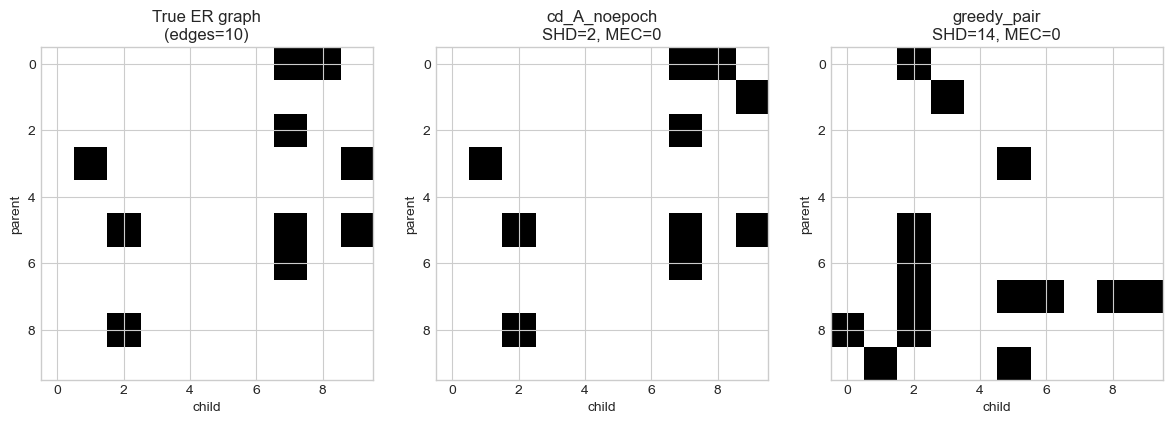

In [34]:
# 5) True / estimated adjacency matrices
alg_names_single = list(results_single.keys())
fig, axes = plt.subplots(1, len(alg_names_single) + 1, figsize=(4 * (len(alg_names_single) + 1), 4))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

axes[0].imshow(trial_single['G_true'], cmap='Greys', vmin=0, vmax=1)
axes[0].set_title(f"True ER graph\n(edges={trial_single['n_edges_true']})")
axes[0].set_xlabel('child')
axes[0].set_ylabel('parent')

for ax, alg_name in zip(axes[1:], alg_names_single):
    G_est = results_single[alg_name]['G_est']
    shd_val = int(df_single.loc[df_single['algorithm'] == alg_name, 'shd'].iloc[0])
    mec_val = int(df_single.loc[df_single['algorithm'] == alg_name, 'mec_match'].iloc[0])
    ax.imshow(G_est, cmap='Greys', vmin=0, vmax=1)
    ax.set_title(f"{alg_name}\nSHD={shd_val}, MEC={mec_val}")
    ax.set_xlabel('child')
    ax.set_ylabel('parent')

plt.tight_layout()
plt.show()


In [1]:
# 6) Single-trial score descent
if not results_single:
    print('Run the single-trial cell first.')
else:
    fig, ax_score = plt.subplots(figsize=(8, 4), constrained_layout=True)

    for alg_name, result in results_single.items():
        history = np.asarray(result['history'], dtype=float)
        if history.size == 0:
            continue
        steps = np.arange(1, history.size + 1)
        color = PLOT_COLORS.get(alg_name, None)
        ax_score.plot(steps, history, linewidth=1.8, label=alg_name, color=color)

    # ax_score.axhline(
    #     trial_single['score_true'],
    #     color='black',
    #     linestyle='--',
    #     linewidth=1.4,
    #     label='true A score',
    # )
    ax_score.set_title('Single-trial objective history')
    ax_score.set_ylim(bottom=trial_single['score_true'] *0.9, top=trial_single['score_true'] *2)
    ax_score.set_xlim(0, 10000)
    ax_score.set_xlabel('Step')
    ax_score.set_ylabel('f(A_t, S)')
    ax_score.grid(True, alpha=0.3)
    ax_score.legend(fontsize=9, loc='best')

    plt.show()


NameError: name 'results_single' is not defined

In [36]:
# 8) Batch ER experiments with different random seeds
batch_runs = []
batch_rows = []
rng = np.random.default_rng(CFG['batch_seed'])
trial_seeds = rng.integers(0, 10**9, size=CFG['batch_trials'])

for trial_id, trial_seed in enumerate(trial_seeds, start=1):
    trial = generate_er_trial(CFG, int(trial_seed))
    results = run_single_experiment(trial['S'], CFG, int(trial_seed))
    batch_runs.append({
        'trial_id': trial_id,
        'seed': int(trial_seed),
        'trial': trial,
        'results': results,
    })
    for alg_name, result in results.items():
        batch_rows.append(make_metrics_row(CFG, trial_id, int(trial_seed), trial, alg_name, result))

        print(
            f"[trial {trial_id:02d}] {alg_name:<16} "
            f"seed={int(trial_seed):>10d}  "
            f"rt={result['runtime_sec']:.3f}s  "
            f"score={result['score']:.4f}"
        )

df_batch = pd.DataFrame(batch_rows).sort_values(['trial_id', 'algorithm']).reset_index(drop=True)
df_batch_summary = summarize_batch(df_batch)

print('\nBatch summary:')
display(df_batch_summary)


[trial 01] cd_A_noepoch     seed= 410660621  rt=5.028s  score=17.0091
[trial 01] greedy_pair      seed= 410660621  rt=8.405s  score=17.9142
[trial 02] cd_A_noepoch     seed= 626202566  rt=5.132s  score=18.2937
[trial 02] greedy_pair      seed= 626202566  rt=2.106s  score=18.4290
[trial 03] cd_A_noepoch     seed= 354313019  rt=5.010s  score=17.1993
[trial 03] greedy_pair      seed= 354313019  rt=15.401s  score=17.5624

Batch summary:


,algorithm,trials,runtime_sec_mean,runtime_sec_std,score_mean,score_gap_true_mean,mec_match_mean,shd_mean,n_edges_est_mean,history_len_mean,monotone_increases_mean
0,cd_A_noepoch,3,5.056665,0.065687,17.500699,-1.777337,0.0,7.333333,14.666667,15000.000000,4.666667
1,greedy_pair,3,8.637266,6.650470,17.968523,-1.309513,0.0,19.333333,15.000000,4942.333333,0.000000


In [37]:
# 9) Save single-trial and batch metrics
if len(df_batch) == 0:
    print('Run the batch cell first.')
else:
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    single_path = os.path.join(CFG['save_dir'], f"{CFG['tag']}_single_{ts}.csv")
    batch_path = os.path.join(CFG['save_dir'], f"{CFG['tag']}_batch_{ts}.csv")
    summary_path = os.path.join(CFG['save_dir'], f"{CFG['tag']}_summary_{ts}.csv")
    latest_single = os.path.join(CFG['save_dir'], f"{CFG['tag']}_single.csv")
    latest_batch = os.path.join(CFG['save_dir'], f"{CFG['tag']}_batch.csv")
    latest_summary = os.path.join(CFG['save_dir'], f"{CFG['tag']}_summary.csv")

    df_single.to_csv(single_path, index=False)
    df_batch.to_csv(batch_path, index=False)
    df_batch_summary.to_csv(summary_path, index=False)
    df_single.to_csv(latest_single, index=False)
    df_batch.to_csv(latest_batch, index=False)
    df_batch_summary.to_csv(latest_summary, index=False)

    print('Saved files:')
    print('  single :', single_path)
    print('  batch  :', batch_path)
    print('  summary:', summary_path)

Saved files:
  single : c:\Users\super\DAG\experiments\results\debug_greedy_er_single_20260331_175725.csv
  batch  : c:\Users\super\DAG\experiments\results\debug_greedy_er_batch_20260331_175725.csv
  summary: c:\Users\super\DAG\experiments\results\debug_greedy_er_summary_20260331_175725.csv


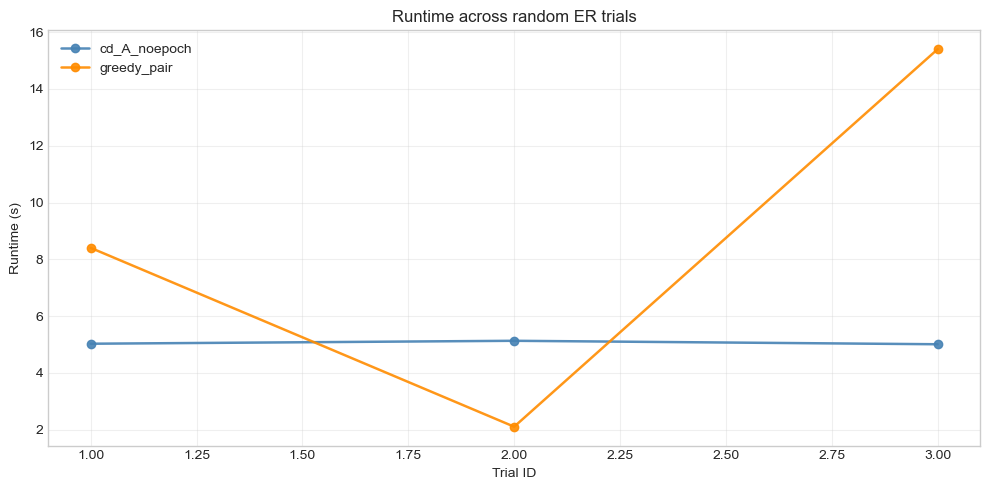

In [38]:
# 10) Runtime per batch trial
if len(df_batch) == 0:
    print('Run the batch cell first.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for alg_name in sorted(df_batch['algorithm'].unique()):
        sub = df_batch[df_batch['algorithm'] == alg_name]
        ax.plot(
            sub['trial_id'],
            sub['runtime_sec'],
            marker='o',
            linewidth=1.8,
            alpha=0.9,
            color=PLOT_COLORS.get(alg_name, None),
            label=alg_name,
        )
    ax.set_xlabel('Trial ID')
    ax.set_ylabel('Runtime (s)')
    ax.set_title('Runtime across random ER trials')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    plt.tight_layout()
    plt.show()

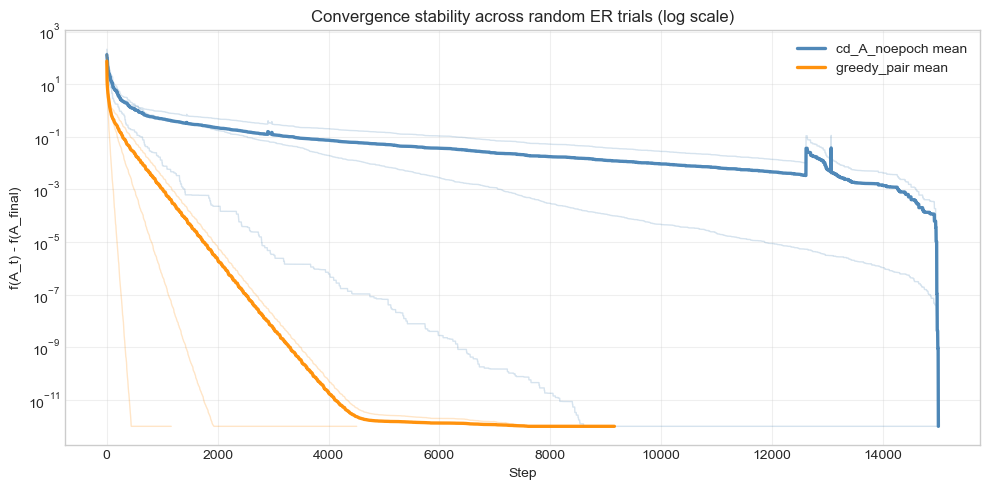

In [39]:
# 11) Batch convergence stability (all trials overlaid)
if not batch_runs:
    print('Run the batch cell first.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    alg_names = list(batch_runs[0]['results'].keys())

    for alg_name in alg_names:
        max_len = max(len(run['results'][alg_name]['history']) for run in batch_runs)
        padded = []
        for run in batch_runs:
            gap = to_gap_to_final(run['results'][alg_name]['history'])
            steps = np.arange(1, len(gap) + 1)
            ax.semilogy(
                steps,
                gap,
                linewidth=1.0,
                alpha=0.22,
                color=PLOT_COLORS.get(alg_name, None),
            )

            pad_val = gap[-1]
            gap_pad = np.full(max_len, pad_val, dtype=float)
            gap_pad[:len(gap)] = gap
            padded.append(gap_pad)

        mean_gap = np.mean(np.vstack(padded), axis=0)
        ax.semilogy(
            np.arange(1, max_len + 1),
            mean_gap,
            linewidth=2.4,
            alpha=0.95,
            color=PLOT_COLORS.get(alg_name, None),
            label=f"{alg_name} mean",
        )

    ax.set_xlabel('Step')
    ax.set_ylabel('f(A_t) - f(A_final)')
    ax.set_title('Convergence stability across random ER trials (log scale)')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10, loc='best')
    plt.tight_layout()
    plt.show()